# White-box auditing of the Gaussian mechanism

This notebook implements a **sample-free white-box audit** for the standard Gaussian mechanism on a fixed neighboring pair.

We assume:

- the outputs on the neighboring pair are Gaussian,
- the means and covariance are known,
- the two outputs have the **same covariance**.

In this setting, the pairwise privacy curve is available in closed form:

$$
\delta(\varepsilon)
= \Phi\!\left(-\frac{\varepsilon}{\tau}+\frac{\tau}{2}\right)
- e^{\varepsilon}\,\Phi\!\left(-\frac{\varepsilon}{\tau}-\frac{\tau}{2}\right),
\qquad
\tau^2 = (\mu_1-\mu_2)^\top \Sigma^{-1}(\mu_1-\mu_2).
$$

So for a fixed neighboring pair, auditing reduces to deterministic numerical evaluation of the normal CDF.

---

## What this notebook does

1. Implements the exact pairwise audit for equal-covariance Gaussian pairs.
2. Specializes it to the standard Gaussian mechanism.
3. Compares **under-noised / calibrated / over-noised** implementations.
4. Produces:
   - privacy curves $\delta(\varepsilon)$,
   - a decision table against a claimed $(\varepsilon_0, \delta_0)$,
   - simple runtime measurements.

You can edit the configuration cell below and rerun the notebook.

In [2]:
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm

plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.float_format', lambda x: f'{x:.6g}')

## Core formulas

In [3]:
def delta_equal_covariance(epsilon, tau):
    """
    Exact pairwise delta(ε) for two Gaussians with equal covariance.

    Parameters
    ----------
    epsilon : float or np.ndarray
        Privacy parameter ε >= 0.
    tau : float
        Mahalanobis distance between the two means under the common covariance.

    Returns
    -------
    float or np.ndarray
        Exact pairwise δ(ε).
    """
    epsilon = np.asarray(epsilon, dtype=float)
    if tau < 0:
        raise ValueError('tau must be nonnegative')
    if np.isclose(tau, 0.0):
        return np.zeros_like(epsilon, dtype=float)

    a = -epsilon / tau + tau / 2.0
    b = -epsilon / tau - tau / 2.0
    delta = norm.cdf(a) - np.exp(epsilon) * norm.cdf(b)
    return np.maximum(delta, 0.0)


def tau_from_gaussian_pair(mu1, mu2, Sigma):
    """
    Compute tau^2 = (mu1-mu2)^T Sigma^{-1} (mu1-mu2).
    """
    mu1 = np.atleast_1d(np.asarray(mu1, dtype=float))
    mu2 = np.atleast_1d(np.asarray(mu2, dtype=float))
    Sigma = np.asarray(Sigma, dtype=float)

    if mu1.shape != mu2.shape:
        raise ValueError('mu1 and mu2 must have the same shape')
    if Sigma.shape != (mu1.size, mu1.size):
        raise ValueError('Sigma must be square with dimension matching mu1/mu2')

    diff = mu1 - mu2
    tau_sq = float(diff.T @ np.linalg.solve(Sigma, diff))
    return np.sqrt(max(tau_sq, 0.0))


def tau_for_gaussian_mechanism(query_gap_l2, sigma):
    """
    For M(D)=q(D)+N(0,sigma^2 I), tau = ||q(D)-q(D')||_2 / sigma.
    """
    if sigma <= 0:
        raise ValueError('sigma must be positive')
    if query_gap_l2 < 0:
        raise ValueError('query_gap_l2 must be nonnegative')
    return query_gap_l2 / sigma


def delta_for_gaussian_mechanism(epsilon, query_gap_l2, sigma):
    tau = tau_for_gaussian_mechanism(query_gap_l2, sigma)
    return delta_equal_covariance(epsilon, tau)


def calibrate_sigma_for_target(epsilon0, delta0, query_gap_l2, sigma_lower=1e-9, sigma_upper=1e6):
    """
    Solve for sigma such that delta(epsilon0) = delta0 for the Gaussian mechanism.
    Returns the smallest positive sigma found by root search.
    """
    if not (0 <= delta0 < 1):
        raise ValueError('delta0 must be in [0, 1)')
    if epsilon0 < 0:
        raise ValueError('epsilon0 must be nonnegative')

    def f(sig):
        return float(delta_for_gaussian_mechanism(epsilon0, query_gap_l2, sig) - delta0)

    # Expand the upper bracket if needed.
    lo, hi = sigma_lower, sigma_upper
    flo, fhi = f(lo), f(hi)

    # delta decreases as sigma increases, so we want flo >= 0 and fhi <= 0.
    if flo < 0:
        raise RuntimeError('Lower bracket is already below target. Try a smaller sigma_lower.')

    while fhi > 0:
        hi *= 10.0
        if hi > 1e18:
            raise RuntimeError('Could not bracket the root. Increase sigma_upper or check inputs.')
        fhi = f(hi)

    return brentq(f, lo, hi, maxiter=1000)


def audit_pair_against_claim(epsilon0, delta0, tau):
    audited_delta = float(delta_equal_covariance(epsilon0, tau))
    decision = 'VIOLATION' if audited_delta > delta0 else 'NO VIOLATION (for this pair)'
    return audited_delta, decision


## User configuration

Edit these values and rerun the notebook.

In [4]:
# Claimed privacy point
EPSILON0 = 1.0
DELTA0 = 1e-5

# Fixed neighboring pair: ||q(D)-q(D')||_2
QUERY_GAP_L2 = 1.0

# Factors relative to the calibrated sigma.
UNDER_FACTOR = 0.8
CALIBRATED_FACTOR = 1.0
OVER_FACTOR = 1.2

# Epsilon grid for plotting the full privacy curve
EPS_GRID = np.linspace(0.01, 5.0, 400)

# Optional explicit Gaussian pair example (for direct white-box pair auditing)
# Uncomment and use if you want to audit an arbitrary equal-covariance Gaussian pair.
# mu1 = np.array([1.0, 0.0])
# mu2 = np.array([0.0, 0.0])
# Sigma = np.eye(2)


## Calibrate the Gaussian mechanism to the claimed privacy point

In [5]:
sigma_calibrated = calibrate_sigma_for_target(EPSILON0, DELTA0, QUERY_GAP_L2)
sigma_under = UNDER_FACTOR * sigma_calibrated
sigma_over = OVER_FACTOR * sigma_calibrated

summary = pd.DataFrame(
    {
        'setting': ['under-noised', 'calibrated', 'over-noised'],
        'sigma': [sigma_under, sigma_calibrated, sigma_over],
        'tau': [
            tau_for_gaussian_mechanism(QUERY_GAP_L2, sigma_under),
            tau_for_gaussian_mechanism(QUERY_GAP_L2, sigma_calibrated),
            tau_for_gaussian_mechanism(QUERY_GAP_L2, sigma_over),
        ],
        'delta_at_epsilon0': [
            float(delta_for_gaussian_mechanism(EPSILON0, QUERY_GAP_L2, sigma_under)),
            float(delta_for_gaussian_mechanism(EPSILON0, QUERY_GAP_L2, sigma_calibrated)),
            float(delta_for_gaussian_mechanism(EPSILON0, QUERY_GAP_L2, sigma_over)),
        ],
    }
)
summary

,setting,sigma,tau,delta_at_epsilon0
0,under-noised,2.98451,0.335064,0.000220276
1,calibrated,3.73063,0.268051,1e-05
2,over-noised,4.47676,0.223376,2.84751e-07


## Exact privacy curves

The plot below mirrors the `fdp-estimation` audit-plot style: the calibrated curve is the claimed reference, the neighboring noise settings are exact audited curves, and the claimed privacy point is emphasized with the deterministic violation gap at $\varepsilon_0$.


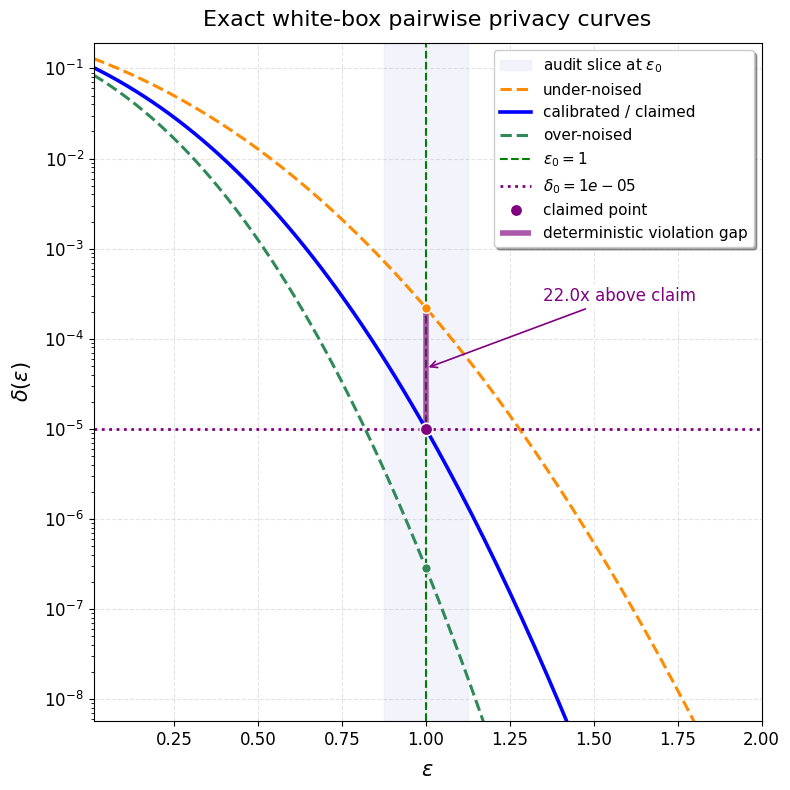

In [6]:
delta_under = delta_for_gaussian_mechanism(EPS_GRID, QUERY_GAP_L2, sigma_under)
delta_cal = delta_for_gaussian_mechanism(EPS_GRID, QUERY_GAP_L2, sigma_calibrated)
delta_over = delta_for_gaussian_mechanism(EPS_GRID, QUERY_GAP_L2, sigma_over)

curve_specs = [
    ('under-noised', delta_under, 'darkorange'),
    ('calibrated / claimed', delta_cal, 'blue'),
    ('over-noised', delta_over, 'seagreen'),
]
delta_at_epsilon0 = {
    'under-noised': float(delta_for_gaussian_mechanism(EPSILON0, QUERY_GAP_L2, sigma_under)),
    'calibrated / claimed': float(delta_for_gaussian_mechanism(EPSILON0, QUERY_GAP_L2, sigma_calibrated)),
    'over-noised': float(delta_for_gaussian_mechanism(EPSILON0, QUERY_GAP_L2, sigma_over)),
}

claim_scale = np.array([DELTA0, *delta_at_epsilon0.values()])
y_lower = max(claim_scale.min() / 50.0, np.nextafter(0.0, 1.0))
y_upper = min(1.0, max(delta_under.max(), delta_cal.max(), delta_over.max(), DELTA0) * 1.5)
x_upper = min(EPS_GRID.max(), EPSILON0 + max(1.0, 0.6 * EPSILON0))

fig, ax = plt.subplots(figsize=(8, 8))

# A narrow band marks the claimed privacy slice being audited.
epsilon_band = 0.025 * (EPS_GRID.max() - EPS_GRID.min())
ax.axvspan(
    EPSILON0 - epsilon_band,
    EPSILON0 + epsilon_band,
    color='lavender',
    alpha=0.45,
    label=r'audit slice at $\varepsilon_0$',
)

for label, values, color in curve_specs:
    linewidth = 2.6 if label == 'calibrated / claimed' else 2.2
    linestyle = '-' if label == 'calibrated / claimed' else '--'
    ax.plot(EPS_GRID, values, color=color, linestyle=linestyle, linewidth=linewidth, label=label)
    ax.plot(
        EPSILON0,
        delta_at_epsilon0[label],
        'o',
        markersize=7,
        color=color,
        markeredgecolor='white',
        markeredgewidth=1.0,
        zorder=5,
    )

ax.axvline(
    EPSILON0,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=rf'$\varepsilon_0={EPSILON0:g}$',
)
ax.axhline(
    DELTA0,
    color='purple',
    linestyle=':',
    linewidth=2.0,
    label=rf'$\delta_0={DELTA0:g}$',
)
ax.plot(
    EPSILON0,
    DELTA0,
    'o',
    markersize=9,
    color='purple',
    markeredgecolor='white',
    markeredgewidth=1.2,
    zorder=6,
    label=r'claimed point',
)

if delta_at_epsilon0['under-noised'] > DELTA0:
    ax.vlines(
        EPSILON0,
        DELTA0,
        delta_at_epsilon0['under-noised'],
        color='purple',
        linewidth=4.0,
        alpha=0.65,
        label='deterministic violation gap',
        zorder=4,
    )
    gap_midpoint = np.sqrt(delta_at_epsilon0['under-noised'] * DELTA0)
    ax.annotate(
        f"{delta_at_epsilon0['under-noised'] / DELTA0:.1f}x above claim",
        xy=(EPSILON0, gap_midpoint),
        xytext=(EPSILON0 + 0.35, delta_at_epsilon0['under-noised'] * 1.35),
        color='purple',
        fontsize=12,
        ha='left',
        va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2.0),
        arrowprops=dict(arrowstyle='->', color='purple', linewidth=1.2),
    )

ax.set_yscale('log')
ax.set_xlim(EPS_GRID.min(), x_upper)
ax.set_ylim(y_lower, y_upper)
ax.set_xlabel(r'$\varepsilon$', fontsize=15, labelpad=8)
ax.set_ylabel(r'$\delta(\varepsilon)$', fontsize=15, labelpad=8)
ax.set_title('Exact white-box pairwise privacy curves', fontsize=16, pad=12)
ax.grid(alpha=0.35, linestyle='--')
ax.tick_params(labelsize=12)
ax.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)

fig.tight_layout()
plt.show()


## Audit decision table at the claimed privacy point

In [7]:
rows = []
for name, sigma in [
    ('under-noised', sigma_under),
    ('calibrated', sigma_calibrated),
    ('over-noised', sigma_over),
]:
    tau = tau_for_gaussian_mechanism(QUERY_GAP_L2, sigma)
    audited_delta, decision = audit_pair_against_claim(EPSILON0, DELTA0, tau)
    rows.append(
        {
            'setting': name,
            'sigma': sigma,
            'tau': tau,
            'claimed_(epsilon0,delta0)': f'({EPSILON0:g}, {DELTA0:g})',
            'audited_delta_at_epsilon0': audited_delta,
            'decision': decision,
        }
    )

audit_table = pd.DataFrame(rows)
audit_table

,setting,sigma,tau,"claimed_(epsilon0,delta0)",audited_delta_at_epsilon0,decision
0,under-noised,2.98451,0.335064,"(1, 1e-05)",0.000220276,VIOLATION
1,calibrated,3.73063,0.268051,"(1, 1e-05)",1e-05,NO VIOLATION (for this pair)
2,over-noised,4.47676,0.223376,"(1, 1e-05)",2.84751e-07,NO VIOLATION (for this pair)
